**Connecting MySql to Python**

In [10]:
!pip install mysql-connector-python

**Import Libraries**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector

**Loading File**

In [12]:
df = pd.read_csv(r"C:\Users\roshini\Downloads\Restaurant Sales.csv")
df.head()

,Date,Day,Time,Order ID,Table Number,Item Name,Category,Quantity,Unit Price,Total Sale,Payment Method,Server Name,Customer Type,Dine Type
0,2024-06-12,Wednesday,11:54 AM,ORD1000,8,Grilled Chicken,Main,3,12.99,38.97,Cash,Bob,New,Delivery
1,2024-05-19,Sunday,11:29 AM,ORD1001,1,Chocolate Cake,Dessert,1,5.99,5.99,Cash,Bob,New,Delivery
2,2024-06-03,Monday,10:27 AM,ORD1002,14,French Fries,Side,5,4.50,22.50,Cash,Diana,Returning,Dine-in
3,2024-02-10,Saturday,09:54 PM,ORD1003,9,Chocolate Cake,Dessert,3,5.99,17.97,Cash,Bob,Returning,Dine-in
4,2024-01-24,Wednesday,04:29 PM,ORD1004,12,Cheeseburger,Main,3,10.49,31.47,Online,Carlos,New,Delivery


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            700 non-null    object 
 1   Day             700 non-null    object 
 2   Time            700 non-null    object 
 3   Order ID        700 non-null    object 
 4   Table Number    700 non-null    int64  
 5   Item Name       700 non-null    object 
 6   Category        700 non-null    object 
 7   Quantity        700 non-null    int64  
 8   Unit Price      700 non-null    float64
 9   Total Sale      700 non-null    float64
 10  Payment Method  700 non-null    object 
 11  Server Name     700 non-null    object 
 12  Customer Type   700 non-null    object 
 13  Dine Type       700 non-null    object 
dtypes: float64(2), int64(2), object(10)
memory usage: 76.7+ KB


In [14]:
df.describe()

,Table Number,Quantity,Unit Price,Total Sale
count,700.000000,700.000000,700.000000,700.000000
mean,10.461429,2.997143,6.516786,19.178200
std,5.762088,1.417242,3.632305,14.521031
min,1.000000,1.000000,2.500000,2.500000
25%,6.000000,2.000000,3.290000,9.580000
50%,10.500000,3.000000,4.990000,13.960000
75%,16.000000,4.000000,10.490000,25.180000
max,20.000000,5.000000,13.490000,67.450000


**Data Cleaning**

**Check missing values**

In [15]:
df.isnull().sum()

Date              0
Day               0
Time              0
Order ID          0
Table Number      0
Item Name         0
Category          0
Quantity          0
Unit Price        0
Total Sale        0
Payment Method    0
Server Name       0
Customer Type     0
Dine Type         0
dtype: int64

**Remove null values**

In [16]:
df = df.dropna()

**Convert Date column**

In [17]:
df['Date'] = pd.to_datetime(df['Date'])

**Convert Time column**

In [21]:
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

C:\Users\roshini\AppData\Local\Temp\ipykernel_16640\479537049.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], errors='coerce')


**Create Month column**

In [22]:
df['Month'] = df['Date'].dt.month_name()

**Create Hour column**

In [23]:
df['Hour'] = df['Time'].dt.hour

**Create Day Name**

In [24]:
df['Day_Name'] = df['Date'].dt.day_name()

In [25]:
df.head()

,Date,Day,Time,Order ID,Table Number,Item Name,Category,Quantity,Unit Price,Total Sale,Payment Method,Server Name,Customer Type,Dine Type,Month,Hour,Day_Name
0,2024-06-12,Wednesday,2026-05-20 11:54:00,ORD1000,8,Grilled Chicken,Main,3,12.99,38.97,Cash,Bob,New,Delivery,June,11,Wednesday
1,2024-05-19,Sunday,2026-05-20 11:29:00,ORD1001,1,Chocolate Cake,Dessert,1,5.99,5.99,Cash,Bob,New,Delivery,May,11,Sunday
2,2024-06-03,Monday,2026-05-20 10:27:00,ORD1002,14,French Fries,Side,5,4.50,22.50,Cash,Diana,Returning,Dine-in,June,10,Monday
3,2024-02-10,Saturday,2026-05-20 21:54:00,ORD1003,9,Chocolate Cake,Dessert,3,5.99,17.97,Cash,Bob,Returning,Dine-in,February,21,Saturday
4,2024-01-24,Wednesday,2026-05-20 16:29:00,ORD1004,12,Cheeseburger,Main,3,10.49,31.47,Online,Carlos,New,Delivery,January,16,Wednesday


**Exploratory Data Analysis (EDA)**

**Total Sales**

In [26]:
total_sales = df['Total Sale'].sum()
print("Total Sales:", total_sales)

Total Sales: 13424.740000000002


**Total Orders**

In [27]:
total_orders = df['Order ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 700


**Average Sales**

In [28]:
avg_sales = df['Total Sale'].mean()
print("Average Sales:", avg_sales)

Average Sales: 19.178200000000004


**Analysis for Each Dashboard Chart**

**Top Selling Menu Items**

In [29]:
top_items = df.groupby('Item Name')['Total Sale'].sum().sort_values(ascending=False).head(10)
print(top_items)

Item Name
Grilled Chicken        1870.56
Cheeseburger           1500.07
Caesar Salad           1076.46
Fish Tacos             1032.38
Spaghetti Bolognese     998.26
Chocolate Cake          928.45
Chicken Wings           773.14
French Fries            769.50
Veggie Pizza            623.48
Iced Tea                577.53
Name: Total Sale, dtype: float64


**Monthly Sales Trend**

In [30]:
monthly_sales = df.groupby('Month')['Total Sale'].sum()
print(monthly_sales)

Month
April       2000.41
February    2146.60
January     2495.72
June        2500.67
March       2406.75
May         1874.59
Name: Total Sale, dtype: float64


**Sales by Category**

In [31]:
category_sales = df.groupby('Category')['Total Sale'].sum()
print(category_sales)

Category
Dessert    2499.24
Drink      1605.24
Main       6024.75
Side       3295.51
Name: Total Sale, dtype: float64


**Payment Method Distribution**

In [32]:
payment = df['Payment Method'].value_counts()
print(payment)

Payment Method
Online    250
Card      238
Cash      212
Name: count, dtype: int64


**Sales by Hour**

In [33]:
hourly_sales = df.groupby('Hour')['Total Sale'].sum()
print(hourly_sales)

Hour
10    1131.53
11    1225.92
12     947.47
13    1331.04
14    1270.25
15     853.06
16     988.49
17    1005.48
18    1063.11
19    1027.72
20    1329.17
21    1244.92
22       6.58
Name: Total Sale, dtype: float64


**Sales by Day**

In [34]:
day_sales = df.groupby('Day_Name')['Total Sale'].sum()
print(day_sales)

Day_Name
Friday       1791.40
Monday       2432.90
Saturday     1555.92
Sunday       1918.78
Thursday     1657.99
Tuesday      1835.98
Wednesday    2231.77
Name: Total Sale, dtype: float64


**Sales by Dine Type**

In [35]:
dine_type_sales = df.groupby('Dine Type')['Total Sale'].sum()
print(dine_type_sales)

Dine Type
Delivery    4745.95
Dine-in     4074.05
Takeaway    4604.74
Name: Total Sale, dtype: float64


**Visualization Using Matplotlib**

**Top Selling Items**

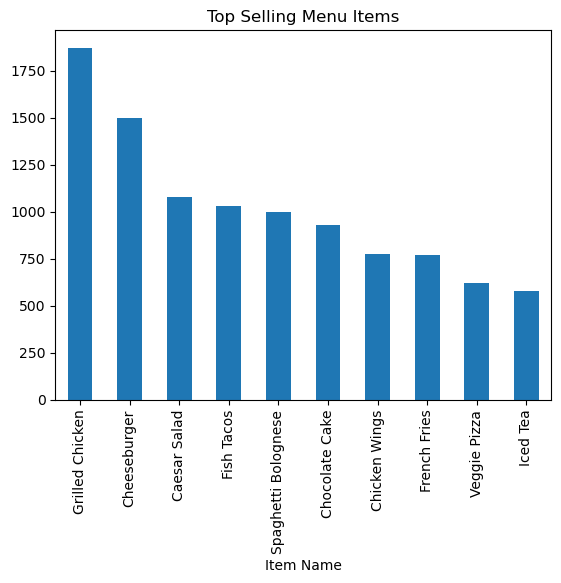

In [36]:
top_items.plot(kind='bar')
plt.title("Top Selling Menu Items")
plt.savefig("top_selling_items.png")
plt.show()

**Monthly Sales Trend**

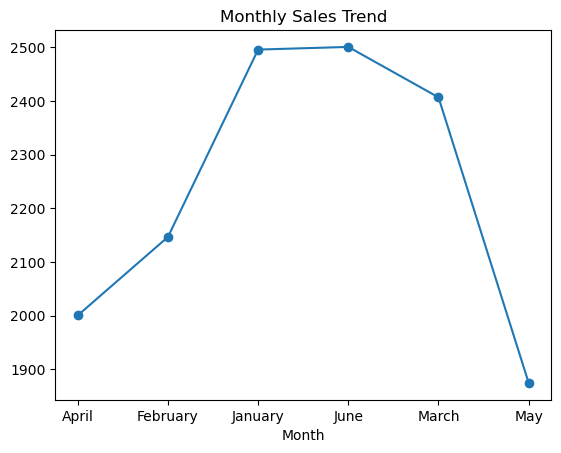

In [37]:
monthly_sales.plot(kind='line',marker='o')
plt.title("Monthly Sales Trend")
plt.savefig("monthly_sales_trend.png")
plt.show()

**Sales by Category**

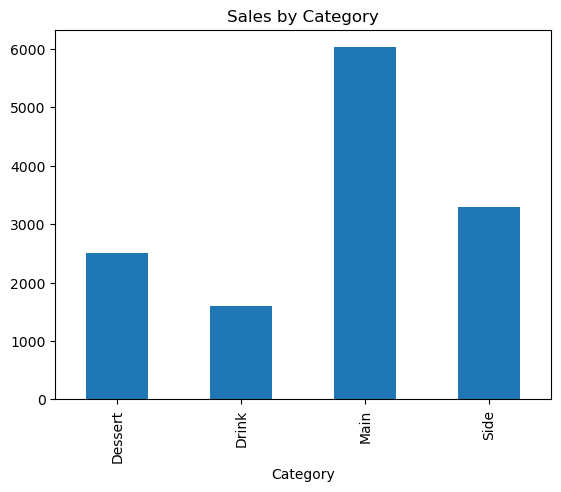

In [38]:
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.savefig("sales_by_category.png")
plt.show()

**Payment Method Distribution**

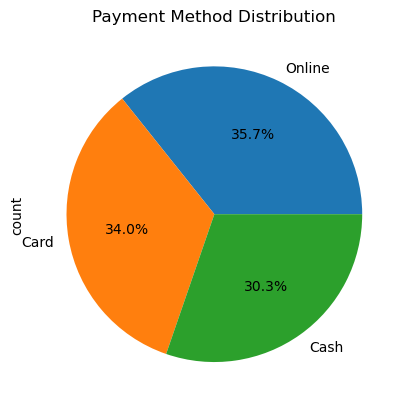

In [39]:
payment.plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.savefig("payment_method_distribution.png")
plt.show()

**Store Data in SQL**

**Connect to MySQL Server**

In [ ]:
import mysql.connector

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Mysql@1234"
)

print("Connected to MySQL successfully")

**Create Database**

In [ ]:
cursor = connection.cursor()
cursor.execute("CREATE DATABASE restaurant_db")

**Connect to the Database**

In [ ]:
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Mysql@1234",
    database="restaurant_db"
)
cursor = connection.cursor()

**Create the table**

In [ ]:
cursor.execute("""
CREATE TABLE sales (
Date DATE,
Time TIME,
Order_ID VARCHAR(20),
Table_Number INT,
Item_Name VARCHAR(100),
Category VARCHAR(50),
Quantity INT,
Unit_Price FLOAT,
Total_Sale FLOAT,
Payment_Method VARCHAR(50),
Server_Name VARCHAR(100),
Customer_Type VARCHAR(50),
Dine_Type VARCHAR(50)
)
""")

**Insert Data from Pandas DataFrame**

In [ ]:
for index,row in df.iterrows():

    sql = """
    INSERT INTO sales VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
    """

    values = (
        row['Date'],
        row['Time'],
        row['Order ID'],
        row['Table Number'],
        row['Item Name'],
        row['Category'],
        row['Quantity'],
        row['Unit Price'],
        row['Total Sale'],
        row['Payment Method'],
        row['Server Name'],
        row['Customer Type'],
        row['Dine Type']
    )

    cursor.execute(sql,values)

connection.commit()

**Verify Data in MySQL**

In [ ]:
cursor.execute("SELECT * FROM sales LIMIT 5")

result = cursor.fetchall()

for row in result:
    print(row)